# Problem 1 - Linear Regression

Estimate the following linear model: y = 1 · X − 1 + €, where X ∈ R^(60×1) consists of generated values from -3 to 3 and € obeys a normal distribution with mean 0 and standard deviation of 0.1.

Train the linear regression model as follows:

    - set the weights and bias to 1
    - set the batch size to 10
    - implement the mean squared error loss
    - implement the mini-batch gradient descent optimizer with lr = 0.05 (do not use the torch.optim package)
    - set the total number of iterations to 25
    
After the model is trained, compare the learned model parameters with the actual parameters.

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(13)
np.random.seed(13)

def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.rand(60, 1) * 6 - 3            # 60 de valori intre 0 si 1, inmultite cu 6 si scazut 3 -> valori intre -3 si 3
    y = X @ w + b
    y += torch.normal(0, 0.1, y.shape)       # epsilon
    return X, y.reshape(-1, 1)               # reshape pentru a obtine un tensor coloana  

true_w = torch.tensor([1.0])   # R -> 60 * 1
true_b = -1.0
features, labels = synthetic_data(true_w, true_b, 60)   # R -> 60 * 1             

In [4]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [5]:
# `nn` is an abbreviation for neural networks
from torch import nn

net = nn.Sequential(nn.Linear(1, 1))              # 1 input, 1 output

net[0].weight.data.fill_(1)
net[0].bias.data.fill_(1)

tensor([1.])

In [6]:
def MyLoss(act, pred):
  return ((act - pred) ** 2).mean()

In [7]:
num_epochs = 25
lr = 0.05

for epoch in range(num_epochs):
    for X, y in data_iter:
        l = MyLoss(net(X), y)

        for param in net.parameters():  #optimizer.zero_grad()
          param.grad.data.zero_() if param.grad is not None else None

        l.backward()

        for param in net.parameters():  #optimizer.step()
          param.data = param.data - lr * param.grad

    l = MyLoss(net(features), labels)
    print(f'Epoch {epoch + 1}, Loss {l:f}')


Epoch 1, Loss 1.121081
Epoch 2, Loss 0.320301
Epoch 3, Loss 0.092990
Epoch 4, Loss 0.031275
Epoch 5, Loss 0.014287
Epoch 6, Loss 0.009344
Epoch 7, Loss 0.008099
Epoch 8, Loss 0.007778
Epoch 9, Loss 0.007654
Epoch 10, Loss 0.007610
Epoch 11, Loss 0.007635
Epoch 12, Loss 0.007625
Epoch 13, Loss 0.007607
Epoch 14, Loss 0.007696
Epoch 15, Loss 0.007612
Epoch 16, Loss 0.007689
Epoch 17, Loss 0.007663
Epoch 18, Loss 0.007608
Epoch 19, Loss 0.007699
Epoch 20, Loss 0.007608
Epoch 21, Loss 0.007614
Epoch 22, Loss 0.007714
Epoch 23, Loss 0.007604
Epoch 24, Loss 0.007610
Epoch 25, Loss 0.007663


In [8]:
w = net[0].weight.data
print('Error in estimating w:', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('Error in estimating b:', true_b - b)

Error in estimating w: tensor([0.0001])
Error in estimating b: tensor([-0.0013])


# Problem 2 - Softmax Regression for MNIST
Implement the softmax regression model in order to classify the images from the MNIST dataset (28 × 28 images of handwritten digits, 10 classes, labels are the digits from 0 to 9, 60000 training images and 10000 testing images) as follows:

- set the batch size to 100
- the validation dataset consists of 30000 images and the rest represents the training dataset
- set the weights to 1
- use the cross-entropy loss function
- use mini-batch stochastic gradient descent with a learning rate of 0.15 as the optimization algorithm
- set the number of epochs to 15
- plot the accuracy for the training and validation sets
- use the trained model to classify 20 images

Evaluate the trained model on the test set.

In [9]:
# imaginile 

import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

In [10]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [30000, 30000],                             # train, validation -> second task
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))


batch_size = 100       # first task

# Use 2 processes to read the data.
train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)

In [11]:
# PyTorch does not implicitly reshape the inputs. Thus, we define the flatten
# layer to reshape the inputs before the linear layer in our network.
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 1.0)            # third task

net.apply(init_weights)

loss = nn.CrossEntropyLoss()                        # fourth task

lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr)        # fifth task

In [12]:
# begin the training process

def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [13]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [14]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [15]:
# the number of epochs to train

num_epochs = 15                                   # sixth task
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

C:\Users\daria\AppData\Local\Temp\ipykernel_48272\3329971113.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 0.77, Train accuracy 74.86, Validation loss 0.56, Validation accuracy 81.22
Epoch 2, Train loss 0.56, Train accuracy 81.07, Validation loss 0.55, Validation accuracy 81.71
Epoch 3, Train loss 0.51, Train accuracy 82.78, Validation loss 0.49, Validation accuracy 83.26
Epoch 4, Train loss 0.49, Train accuracy 83.23, Validation loss 0.55, Validation accuracy 82.10
Epoch 5, Train loss 0.47, Train accuracy 83.79, Validation loss 0.46, Validation accuracy 84.37
Epoch 6, Train loss 0.46, Train accuracy 84.18, Validation loss 0.47, Validation accuracy 84.03


KeyboardInterrupt: 

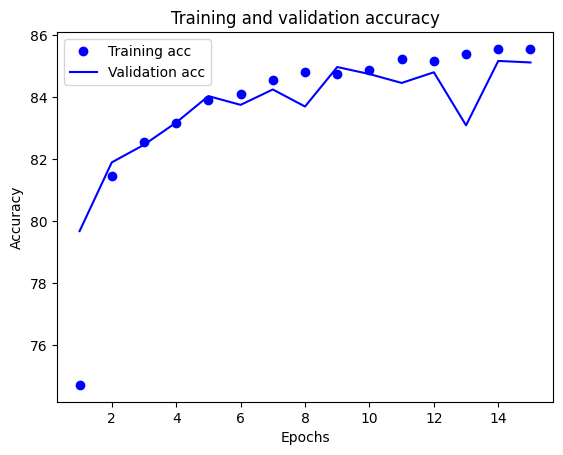

In [ ]:
import matplotlib.pyplot as plt
#seventh task
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [ ]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 0.46, Test accuracy 83.86


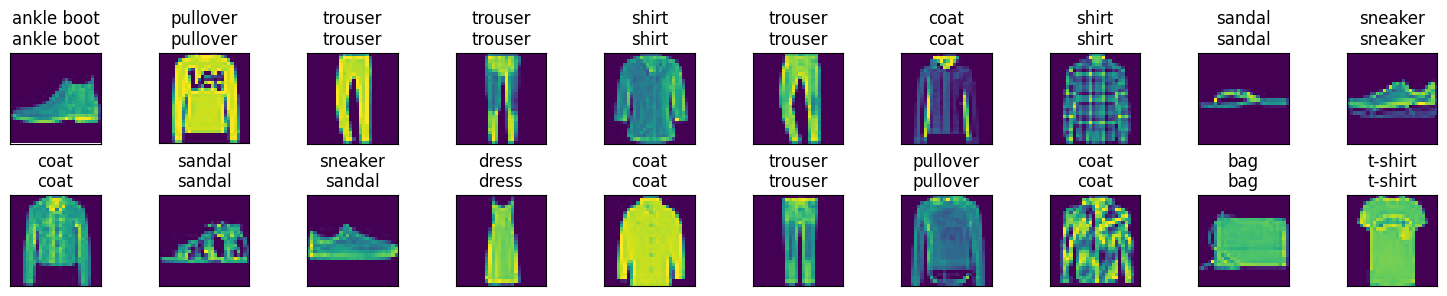

In [ ]:
def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]


def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes


def predict(net, test_iter, n=20):   # eigth task
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Problem 3 - MLP for MNIST Classification

Classify the MNIST dataset (28 × 28 images, 10 classes, 60000 training images and 10000 testing images) using an MLP as follows:

- two hidden layers with 256 units
- add the hyperbolic tangent activation function and a dropout layer after each hidden layer (dropout probability of 40%)
- use 45000 training images and 15000 validation images
- use the cross-entropy loss function
- apply Xavier initialization to the weights and set the biases to zero
- set the batch size to 512 and the learning rate to 0.15
- train the model for 10 epochs

Evaluate the trained model on the test set.

In [17]:
import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes



def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [45000, 15000], #45000 training images, 15000 validation images
                                                           generator=torch.Generator().manual_seed(33))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

batch_size = 512

train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)

In [21]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.Tanh(),
                    nn.Dropout(0.4),
                    nn.Linear(256, 256),
                    nn.Tanh(),
                    nn.Dropout(0.4),
                    nn.Linear(256, 10))

print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)


In [22]:
loss = nn.CrossEntropyLoss()

In [23]:
def xavier(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

net.apply(xavier)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

In [24]:
batch_size, lr, num_epochs = 512, 0.15, 10

In [25]:
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 0.87, Train accuracy 68.74, Validation loss 0.59, Validation accuracy 78.75
Epoch 2, Train loss 0.61, Train accuracy 78.10, Validation loss 0.52, Validation accuracy 81.61
Epoch 3, Train loss 0.56, Train accuracy 79.50, Validation loss 0.52, Validation accuracy 81.75
Epoch 4, Train loss 0.53, Train accuracy 81.07, Validation loss 0.46, Validation accuracy 83.53
Epoch 5, Train loss 0.51, Train accuracy 81.83, Validation loss 0.44, Validation accuracy 84.20
Epoch 6, Train loss 0.50, Train accuracy 82.39, Validation loss 0.45, Validation accuracy 84.01
Epoch 7, Train loss 0.49, Train accuracy 82.64, Validation loss 0.44, Validation accuracy 84.19
Epoch 8, Train loss 0.48, Train accuracy 82.99, Validation loss 0.42, Validation accuracy 84.81
Epoch 9, Train loss 0.46, Train accuracy 83.38, Validation loss 0.42, Validation accuracy 85.07
Epoch 10, Train loss 0.46, Train accuracy 83.52, Validation loss 0.44, Validation accuracy 84.66


In [26]:
test_loss, test_acc = evaluate_accuracy(net, test_iter) #evaluate trained model on test set
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 0.47, Test accuracy 83.33
